# Wave climate reference (Metocean gap)

`WaveHeight`/`WavePeriod` are required inputs to the IEA monopile mass surrogate (see
`../Components/foundations.py`) but aren't produced anywhere in this project yet -- this
notebook documents the best real candidate found so far, kept as an explicit gap rather
than a made-up number.

**References**
- NOAA National Data Buoy Center, Station 44097 (Block Island, RI, 40.967N 71.124W),
  historical standard meteorological data, 2024.
- Barthelmie, R.J., Dantuono, K.E., Renner, E.J., Letson, F.L., Pryor, S.C. (2021).
  "Extreme Wind and Waves in U.S. East Coast Offshore Wind Energy Lease Areas."
  *Energies*, 14(4), 1053. https://www.mdpi.com/1996-1073/14/4/1053
- Cross-checked seasonal trend against National Academies (2024) Nantucket Shoals
  climatology (Hs ~1.0 m in July, ~2.4 m in Dec-Jan).


In [1]:
import pandas as pd

df = pd.read_csv('data/ndbc_44097_block_island_2024.txt', sep=r'\s+', skiprows=[1])
for col in ['WVHT', 'DPD', 'APD']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df.loc[df[col] > 90, col] = None

annual = df[['WVHT', 'DPD', 'APD']].mean()
print("Station 44097 - Block Island, RI -- annual means (2024)")
print(annual.round(2))


Station 44097 - Block Island, RI -- annual means (2024)
WVHT    1.38
DPD     7.68
APD     5.34
dtype: float64


In [2]:
monthly = df.groupby('MM')[['WVHT', 'DPD']].mean().round(2)
monthly.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly


,WVHT,DPD
Jan,1.83,7.87
Feb,1.54,8.37
Mar,1.76,7.87
Apr,1.38,8.47
May,0.99,7.07
Jun,0.95,6.40
Jul,1.12,7.30
Aug,1.14,7.64
Sep,1.28,8.25
Oct,1.32,8.78


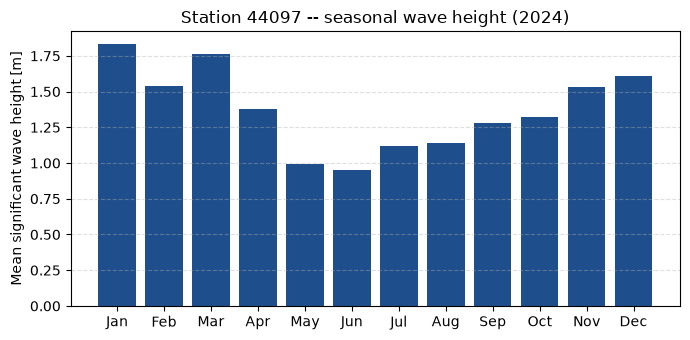

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(monthly.index, monthly['WVHT'], color='#1f4e8c')
ax.set_ylabel('Mean significant wave height [m]')
ax.set_title('Station 44097 -- seasonal wave height (2024)')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [4]:
print(f"July mean Hs:      {monthly.loc['Jul','WVHT']} m  (National Academies: ~1.0 m)")
print(f"Dec-Jan mean Hs:   {((monthly.loc['Dec','WVHT'] + monthly.loc['Jan','WVHT']) / 2):.2f} m  (National Academies: ~2.4 m)")


July mean Hs:      1.12 m  (National Academies: ~1.0 m)
Dec-Jan mean Hs:   1.72 m  (National Academies: ~2.4 m)


**Status**: real, citable candidate values -- not yet wired into `foundations.py`.
Kept as an explicit placeholder until the foundation surrogate integration decides how
this feeds `WaveHeight`/`WavePeriod`.
